# 🚀 Gradient Boosting Regressor — Hotel Price Prediction

Train a Gradient Boosting Regressor with hyperparameter tuning on Indian hotel pricing data.

**Prerequisites**: Run `01_data_exploration.ipynb` first.

---

## 1. Setup

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Preprocessed Data

In [3]:
data = np.load('models/train_test_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# Load feature names saved by notebook 01
feature_names = joblib.load('models/feature_names.pkl')

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')
print(f'Features:         {X_train.shape[1]}')
print(f'Feature names:    {feature_names}')

Training samples: 464
Test samples:     116
Features:         8
Feature names:    ['Rating', 'Reviews', 'Star Rating', 'City', 'Rating Desc', 'Has Landmark', 'Distance km', 'Tax']


## 3. Train Gradient Boosting with Hyperparameter Tuning

In [4]:
# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
}

print('🔍 Running Grid Search (this may take several minutes)...')

gb_base = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(
    gb_base, param_grid,
    cv=5, scoring='r2',
    verbose=1, n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f'\n✅ Best Parameters: {grid_search.best_params_}')
print(f'✅ Best CV R² Score: {grid_search.best_score_:.4f}')

🔍 Running Grid Search (this may take several minutes)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
✅ Best CV R² Score: -0.8614


In [5]:
# Use best model
gb_model = grid_search.best_estimator_

# Cross-validation
cv_scores = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='r2')
print(f'Cross-Validation R² Scores: {cv_scores}')
print(f'Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation R² Scores: [ 0.65346348  0.19609428  0.10713747 -1.88280523 -3.38074616]
Mean CV R²: -0.8614 ± 1.5324


## 4. Evaluate Model

In [6]:
y_train_pred = gb_model.predict(X_train)
y_test_pred = gb_model.predict(X_test)

train_metrics = {
    'MAE': mean_absolute_error(y_train, y_train_pred),
    'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
    'R² Score': r2_score(y_train, y_train_pred)
}

test_metrics = {
    'MAE': mean_absolute_error(y_test, y_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
    'R² Score': r2_score(y_test, y_test_pred)
}

print('📊 Training Metrics:')
for k, v in train_metrics.items():
    print(f'   {k}: {v:.4f}')

print('\n📊 Test Metrics:')
for k, v in test_metrics.items():
    print(f'   {k}: {v:.4f}')

📊 Training Metrics:
   MAE: 789.8134
   RMSE: 1327.6924
   R² Score: 0.9630

📊 Test Metrics:
   MAE: 1018.7623
   RMSE: 1586.2308
   R² Score: 0.7456


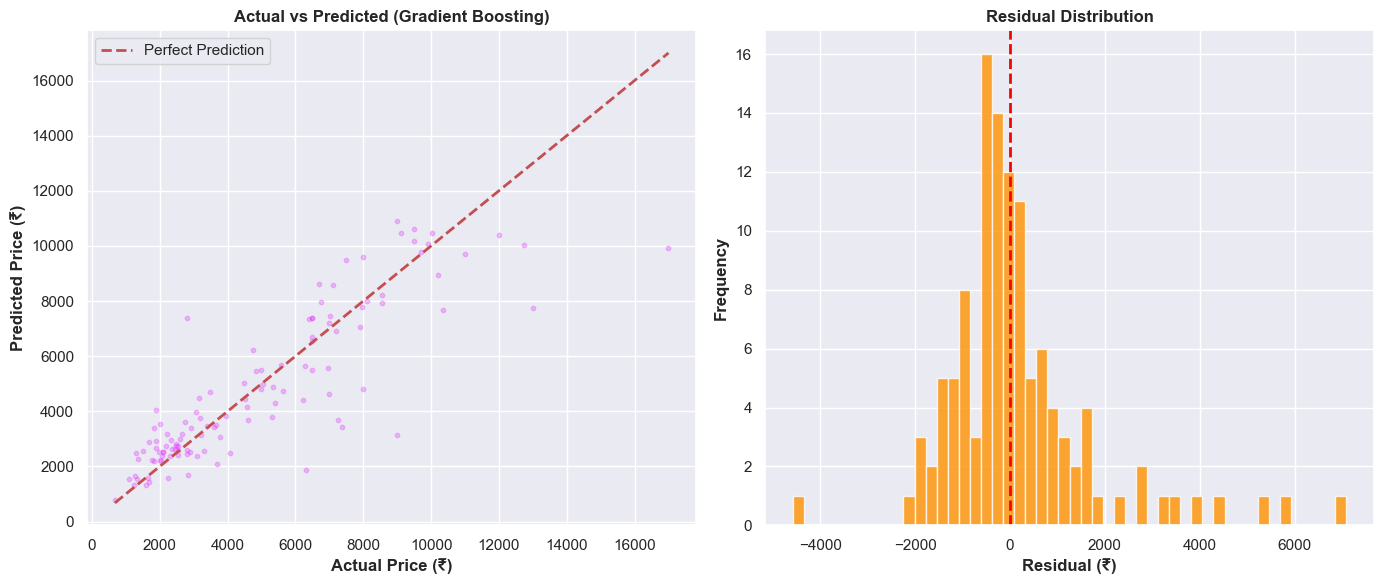

In [7]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_test_pred, alpha=0.3, c='#e040fb', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (₹)', fontweight='bold')
axes[0].set_ylabel('Predicted Price (₹)', fontweight='bold')
axes[0].set_title('Actual vs Predicted (Gradient Boosting)', fontweight='bold')
axes[0].legend()

residuals = y_test - y_test_pred
axes[1].hist(residuals, bins=50, color='#ff9100', alpha=0.8, edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (₹)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

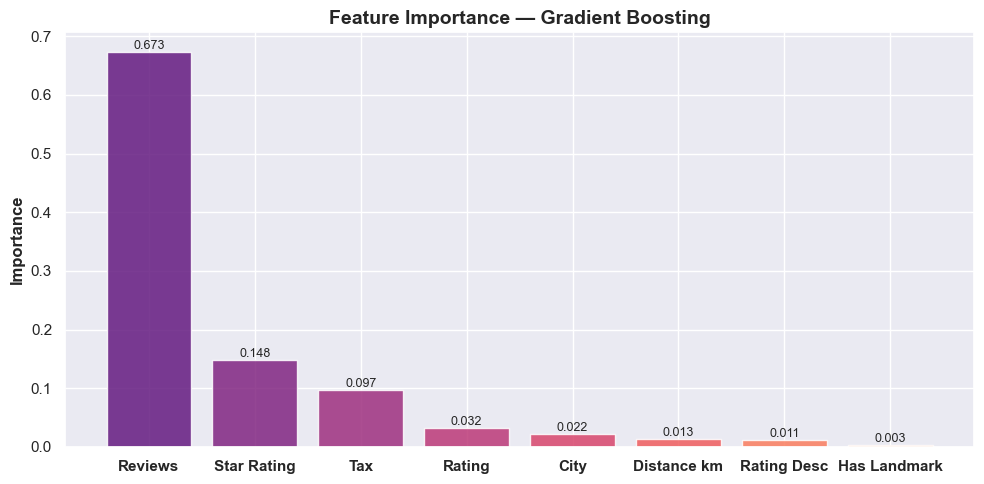

In [8]:
# Feature Importance
importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.magma(np.linspace(0.3, 0.8, len(feature_names)))
ax.bar(range(len(feature_names)), importances[indices], color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices], fontweight='bold')
ax.set_ylabel('Importance', fontweight='bold')
ax.set_title('Feature Importance — Gradient Boosting', fontweight='bold', fontsize=14)

for i, (idx, imp) in enumerate(zip(indices, importances[indices])):
    ax.text(i, imp + 0.005, f'{imp:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

📈 Generating learning curve...


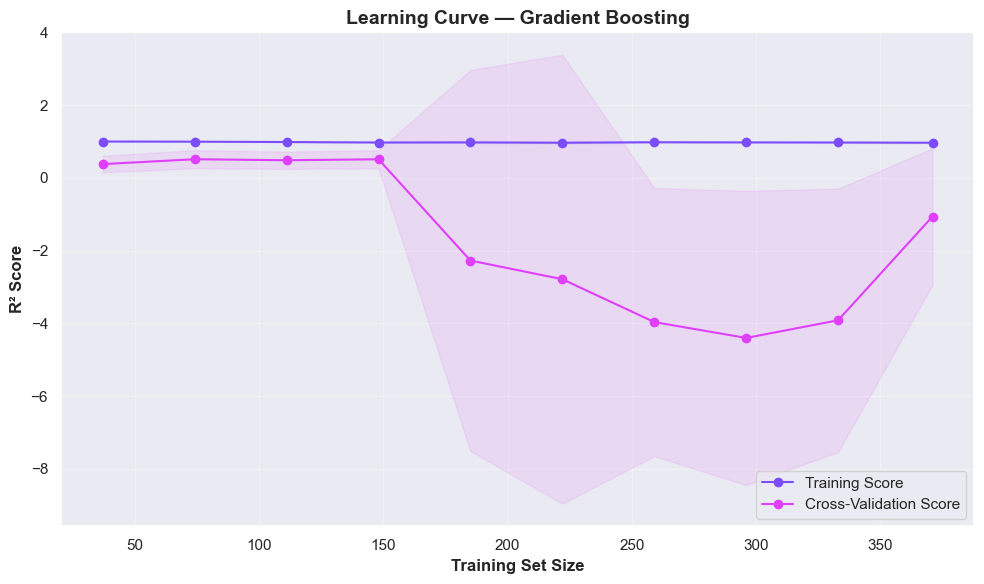

In [9]:
# Learning Curve
print('📈 Generating learning curve...')
train_sizes, train_scores, test_scores = learning_curve(
    gb_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='r2', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#7c4dff')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='#e040fb')
ax.plot(train_sizes, train_mean, 'o-', color='#7c4dff', label='Training Score')
ax.plot(train_sizes, test_mean, 'o-', color='#e040fb', label='Cross-Validation Score')
ax.set_xlabel('Training Set Size', fontweight='bold')
ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('Learning Curve — Gradient Boosting', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Save Model

In [10]:
os.makedirs('models', exist_ok=True)
model_path = 'models/gradient_boosting.pkl'
joblib.dump(gb_model, model_path)

print(f'✅ Model saved to: {model_path}')
print(f'   File size: {os.path.getsize(model_path) / 1024:.1f} KB')
print(f'   Best params: {grid_search.best_params_}')
print(f'\n📊 Final Test R² Score: {test_metrics["R² Score"]:.4f}')

✅ Model saved to: models/gradient_boosting.pkl
   File size: 172.8 KB
   Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

📊 Final Test R² Score: 0.7456


## 6. Model Comparison Summary

In [11]:
# Load all models and compare
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

models_to_compare = {}

if os.path.exists('models/linear_regression.pkl'):
    models_to_compare['Linear Regression'] = joblib.load('models/linear_regression.pkl')
if os.path.exists('models/random_forest.pkl'):
    models_to_compare['Random Forest'] = joblib.load('models/random_forest.pkl')
models_to_compare['Gradient Boosting'] = gb_model

print('📊 Model Comparison on Test Set:\n')
print(f'{"Model":<25} {"MAE":>10} {"RMSE":>10} {"R²":>10}')
print('-' * 57)

comparison_data = []
for name, model in models_to_compare.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f'{name:<25} {mae:>10.2f} {rmse:>10.2f} {r2:>10.4f}')
    comparison_data.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})

📊 Model Comparison on Test Set:

Model                            MAE       RMSE         R²
---------------------------------------------------------
Linear Regression            2034.49    2597.27     0.3178
Random Forest                1292.73    2513.90     0.3609
Gradient Boosting            1018.76    1586.23     0.7456


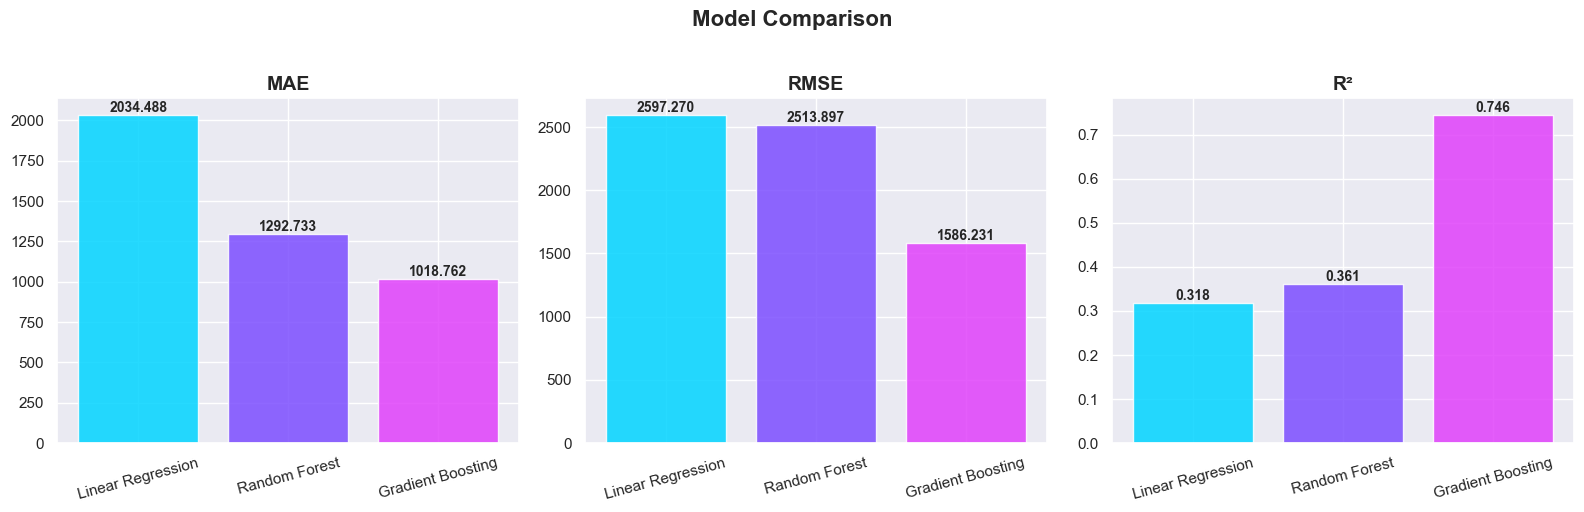

In [12]:
# Comparison visualization
if len(comparison_data) > 1:
    comp_df = pd.DataFrame(comparison_data)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colors = ['#00d4ff', '#7c4dff', '#e040fb']

    for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
        bars = axes[i].bar(comp_df['Model'], comp_df[metric], color=colors[:len(comp_df)],
                          alpha=0.85, edgecolor='white')
        axes[i].set_title(metric, fontweight='bold', fontsize=14)
        axes[i].tick_params(axis='x', rotation=15)

        for bar, val in zip(bars, comp_df[metric]):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.suptitle('Model Comparison', fontweight='bold', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [13]:
print('\n🎉 All Models Trained Successfully!')
print('\nSaved models in models/ directory:')
for f in os.listdir('models'):
    size = os.path.getsize(os.path.join('models', f)) / 1024
    print(f'   {f} ({size:.1f} KB)')

print('\n▶️ Next Steps:')
print('  1. Download .pkl files from models/ directory')
print('  2. Place them in the local ML_LabProject/models/ folder')
print('  3. Run: python app.py')
print('  4. Open: http://127.0.0.1:5000')


🎉 All Models Trained Successfully!

Saved models in models/ directory:
   feature_names.pkl (0.1 KB)
   gradient_boosting.pkl (172.8 KB)
   label_encoders.pkl (0.9 KB)
   linear_regression.pkl (0.7 KB)
   processed_data.csv (65.0 KB)
   random_forest.pkl (3000.8 KB)
   scaler.pkl (0.8 KB)
   train_test_data.npz (41.8 KB)

▶️ Next Steps:
  1. Download .pkl files from models/ directory
  2. Place them in the local ML_LabProject/models/ folder
  3. Run: python app.py
  4. Open: http://127.0.0.1:5000
